# Online Retail Sales & Customer Behavior Analysis

## 1.🧑‍💻 Introduction

This project focuses on analyzing an Online Retail Sales dataset to understand sales patterns, customer behavior, product performance, and other useful business trends.

The analysis follows a structured data analysis process, starting with understanding and investigating the dataset, followed by data cleaning, feature creation, exploratory data analysis, visualization, and insight generation.

The main objective is to transform raw transactional data into meaningful information and identify patterns that can support better business understanding and decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("C:/Users/vikasa s y/Downloads/Online-Retail-Sales-Analysis/Data/Online Retail.xlsx")

## 2. Understanding The DataSet

In [3]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [6]:
df.shape

(541909, 8)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(5268)

In [11]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

### 🧠 Dataset Understanding
- Our dataSet Contains **541909 Rows** And **8 Columns**
- The DataSet Conatins Some Missing Values Especially In **Description and CustomerID** Columns
- The Dataset Contains **5268** No Duplicate Rows
- In **Quantity and UnitPrice** Columns It Conatins Negitive Values That Require Further Investigation
- **Country And Description** Are The Categorical Data

---
---
## 3. Data Investigation

In [12]:
df["Quantity"].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [13]:
df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [14]:
df["UnitPrice"].min()

np.float64(-11062.06)

In [15]:
df["UnitPrice"].max()

np.float64(38970.0)

In [16]:
df["Quantity"].max()

np.int64(80995)

In [17]:
df["Quantity"].min()

np.int64(-80995)

In [18]:
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [19]:
df[df["UnitPrice"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [20]:
df[df["UnitPrice"] == 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [21]:
df[df["Quantity"] < 0]["InvoiceNo"].head(20)

141     C536379
154     C536383
235     C536391
236     C536391
237     C536391
238     C536391
239     C536391
240     C536391
241     C536391
939     C536506
1441    C536543
1442    C536543
1973    C536548
1974    C536548
1975    C536548
1976    C536548
1977    C536548
1978    C536548
1979    C536548
1980    C536548
Name: InvoiceNo, dtype: object

In [22]:
(df["UnitPrice"] < 0).sum()

np.int64(2)

In [23]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [24]:
(df["UnitPrice"] == 0).sum()

np.int64(2515)

In [25]:
df.loc[df["Quantity"].idxmax()]

InvoiceNo                           581483
StockCode                            23843
Description    PAPER CRAFT , LITTLE BIRDIE
Quantity                             80995
InvoiceDate            2011-12-09 09:15:00
UnitPrice                             2.08
CustomerID                         16446.0
Country                     United Kingdom
Name: 540421, dtype: object

In [26]:
df.loc[df["Quantity"].idxmin()]

InvoiceNo                          C581484
StockCode                            23843
Description    PAPER CRAFT , LITTLE BIRDIE
Quantity                            -80995
InvoiceDate            2011-12-09 09:27:00
UnitPrice                             2.08
CustomerID                         16446.0
Country                     United Kingdom
Name: 540422, dtype: object

### Investigation Findings
- `Description` Has **1454 Missing Values**
- `CustomerID` Have  **135080 Missing Values**
- `Quantity` Contains Negitive Values.
- Negative quantities are associated with invoice numbers beginning with `C`, indicating cancellation/return transactions.
- The dataset contains **10,624 negative UnitPrice values**, including records related to `Adjust bad debt`.
- There are **2,515 transactions with UnitPrice = 0**.
- An extreme quantity of **80,995** was found, along with a corresponding cancellation of **-80,995** for the same product.

### Initial Understanding

The unusual values are not automatically treated as errors. They represent different types of business transactions or special records. Therefore, cleaning decisions will be based on the purpose of the analysis rather than simply removing unusual values.

---
---
## 4.🧹 Data Cleaning

Based on the data investigation, several data-quality issues were identified, including missing values, duplicate records, cancellation transactions, unusual prices, and special transaction records.

The cleaning process will address these issues while preserving the original dataset. Each cleaning decision will be based on the purpose of the analysis and the meaning of the data.


In [27]:
df.shape

(541909, 8)

In [28]:
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.0,United Kingdom


In [29]:
clean_df = df.drop_duplicates().copy()

In [30]:
clean_df.shape

(536641, 8)

### Duplicate Handling

- The dataset contained **5,268 exact duplicate rows**.
- These duplicate records were removed from the analysis dataset.
- The original dataset was preserved for reference.
- After removing duplicates, the dataset contains **536,641 rows**.

In [31]:
clean_df["CustomerID"].isna().sum()

np.int64(135037)

### CustomerID Missing Values

- A significant number of records have missing **CustomerID** values.
- These records are retained because `CustomerID` is not required for overall sales, product, country, or time-based analysis.
- Records with missing `CustomerID` will be excluded only when performing **customer-specific analysis**.

In [32]:
clean_df[clean_df["Description"].isna()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


---
---
### Handling Missing `Description`

In [33]:
clean_df = clean_df.dropna(subset=["Description"]).copy()

In [34]:
clean_df["Description"].isna().sum()

np.int64(0)

### Missing Description

- The dataset contained missing values in the `Description` column.
- Investigation showed that these records generally had a **UnitPrice of 0** and missing customer information.
- Since product-level analysis depends on identifying the product, records with missing descriptions were removed from the cleaned sales dataset.

---
---
### Handling Negative `Quantity`

In [35]:
Returns_df = df[df["Quantity"] < 0]

In [36]:
Returns_df.shape

(10624, 8)

In [37]:
sales_df = clean_df[clean_df["Quantity"] > 0].copy()

In [38]:
sales_df.shape

(525462, 8)

### Negative Quantity / Returns

- The original dataset contains **10,624 transactions with negative quantities**.
- These transactions are treated as return or cancellation records rather than invalid data.
- They are preserved separately in `returns_df`.
- A separate `sales_df` is created using positive quantities for normal sales analysis.

In [39]:
zero_qnty = df[df["Quantity"] == 0]

In [40]:
zero_qnty.shape

(0, 8)

In [41]:
zero_qnty.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


### Handling `UnitPrice`

In [42]:
negative_price = df[df["UnitPrice"] < 0]

In [43]:
negative_price.shape

(2, 8)

In [44]:
negative_price.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [45]:
clean_df[clean_df["UnitPrice"] <= 0].shape

(1058, 8)

In [46]:
clean_df[clean_df["UnitPrice"] <= 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
6391,536941,22734,amazon,20,2010-12-03 12:08:00,0.0,NaN,United Kingdom
6392,536942,22139,amazon,15,2010-12-03 12:08:00,0.0,NaN,United Kingdom
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.0,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
13217,537425,84968F,check,-20,2010-12-06 15:35:00,0.0,NaN,United Kingdom
13218,537426,84968E,check,-35,2010-12-06 15:36:00,0.0,NaN,United Kingdom
13264,537432,35833G,damages,-43,2010-12-06 16:10:00,0.0,NaN,United Kingdom
14335,537534,85064,CREAM SWEETHEART LETTER RACK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom
14336,537534,84832,ZINC WILLIE WINKIE CANDLE STICK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom
14337,537534,84692,BOX OF 24 COCKTAIL PARASOLS,2,2010-12-07 11:48:00,0.0,NaN,United Kingdom


In [47]:
clean_df[clean_df["UnitPrice"] == 0].shape

(1056, 8)

In [48]:
clean_df[clean_df["UnitPrice"] == 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
6391,536941,22734,amazon,20,2010-12-03 12:08:00,0.0,NaN,United Kingdom
6392,536942,22139,amazon,15,2010-12-03 12:08:00,0.0,NaN,United Kingdom
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.0,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
13217,537425,84968F,check,-20,2010-12-06 15:35:00,0.0,NaN,United Kingdom
13218,537426,84968E,check,-35,2010-12-06 15:36:00,0.0,NaN,United Kingdom
13264,537432,35833G,damages,-43,2010-12-06 16:10:00,0.0,NaN,United Kingdom
14335,537534,85064,CREAM SWEETHEART LETTER RACK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom
14336,537534,84832,ZINC WILLIE WINKIE CANDLE STICK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom
14337,537534,84692,BOX OF 24 COCKTAIL PARASOLS,2,2010-12-07 11:48:00,0.0,NaN,United Kingdom


### UnitPrice Analysis

- The `UnitPrice` column contains the price of each product per unit.
- The analysis identified **negative and zero UnitPrice values** that do not represent normal sales.
- Negative UnitPrice values were investigated and found to be associated with unusual financial adjustment records.
- Zero UnitPrice records represent transactions with no recorded sales price.
- Therefore, records with **UnitPrice <= 0** will be excluded from the normal sales analysis.
- Records with positive UnitPrice values will be retained for revenue and sales analysis.

---
---
### Extreme Quantity Values

- The dataset contains unusually large positive and negative quantity values.
- Investigation showed that the extreme values are associated with corresponding sales and cancellation transactions.
- Therefore, extreme quantities were not removed solely because they were large.
- Outlier treatment will only be considered when it is justified by the specific analysis being performed.

In [49]:
sales_df = clean_df[ (clean_df["Quantity"] > 0) & (clean_df["UnitPrice"] > 0) ].copy() 

In [50]:
sales_df.shape

(524878, 8)

In [51]:
sales_df.duplicated().sum()

np.int64(0)

In [52]:
sales_df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
dtype: int64

In [53]:
(sales_df["Quantity"] <= 0).sum()

np.int64(0)

In [54]:
(sales_df["UnitPrice"] <= 0).sum()

np.int64(0)

### Data Cleaning - Summary

The dataset was cleaned based on the findings from the initial data investigation.

- Removed **5,268 duplicate rows**.
- Retained records with missing `CustomerID` because they are still useful for overall sales analysis.
- Removed records with missing `Description` from the sales dataset.
- Separated **10,624 negative-quantity transactions** as returns/cancellations.
- Excluded transactions with `UnitPrice <= 0` from the normal sales dataset.
- Extreme quantity values were investigated and were not removed without sufficient justification.
- Created `sales_df` containing **524,878 valid sales transactions** for further analysis.

The original dataset was preserved, while the cleaned sales dataset will be used for feature creation and further exploratory analysis.

## 5. Feature Creation

### 💰 Feature 1 — Revenue Creation & Analysis

The dataset contains `Quantity` and `UnitPrice`, but it does not directly provide the total revenue generated by each transaction.

To support sales and business analysis, a new `Revenue` feature was created using:

**Revenue = Quantity × UnitPrice**

After creating the feature, its basic statistics were examined and revenue was analyzed to understand:

* Which products generate the most revenue
* How revenue changes over time
* Which months generate higher sales revenue
* Whether revenue patterns are related to sales quantity and unit price

The `Revenue` feature will be used in further sales and business analysis.


In [55]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

In [56]:
sales_df["Revenue"].describe()

count    524878.000000
mean         20.275399
std         271.693566
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64

In [57]:
sales_df["Revenue"].head(10)

0    15.30
1    20.34
2    22.00
3    20.34
4    20.34
5    15.30
6    25.50
7    11.10
8    11.10
9    54.08
Name: Revenue, dtype: float64

In [58]:
sales_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [59]:
sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"])

In [60]:
sales_df["InvoiceDate"].dtypes

dtype('<M8[us]')

In [61]:
sales_df['InvoiceDate'].min()

Timestamp('2010-12-01 08:26:00')

In [62]:
sales_df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

### 📅 Feature 2 - Time-Based Analysis

The `InvoiceDate` column contains the date and time of each transaction.
Time-based analysis helps identify **sales trends, order patterns, and periods of higher or lower business activity**.

In this feature, we will investigate:

* Monthly revenue
* Monthly quantity sold
* Monthly number of unique orders
* Order activity across different days of the week


In [63]:
sales_df['InvoiceDate'].dt.month.value_counts().sort_index()

InvoiceDate
1     34060
2     26882
3     35497
4     28882
5     35917
6     35716
7     38395
8     34264
9     48900
10    58537
11    82004
12    65824
Name: count, dtype: int64

In [64]:
sales_df = clean_df[(clean_df["Quantity"] > 0) & (clean_df["UnitPrice"] > 0)].copy()

In [65]:
sales_df["InvoiceDate"].head()

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[us]

In [66]:
sales_df["InvoiceDate"].dtype

dtype('<M8[us]')

In [67]:
sales_df["InvoiceDate"].dt.month.value_counts().sort_index()

InvoiceDate
1     34060
2     26882
3     35497
4     28882
5     35917
6     35716
7     38395
8     34264
9     48900
10    58537
11    82004
12    65824
Name: count, dtype: int64

In [68]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

In [69]:
# finding month's Revenue 
sales_df.groupby(sales_df["InvoiceDate"].dt.month)["Revenue"].sum()

InvoiceDate
1      689811.610
2      522545.560
3      716215.260
4      536968.491
5      769296.610
6      760547.010
7      718076.121
8      757841.380
9     1056435.192
10    1151263.730
11    1503866.780
12    1459243.060
Name: Revenue, dtype: float64

In [70]:
# sorting values according to highest sales
sales_df.groupby(sales_df["InvoiceDate"].dt.month)["Revenue"].sum().sort_values(ascending=False)

InvoiceDate
11    1503866.780
12    1459243.060
10    1151263.730
9     1056435.192
5      769296.610
6      760547.010
8      757841.380
7      718076.121
3      716215.260
1      689811.610
4      536968.491
2      522545.560
Name: Revenue, dtype: float64

In [71]:
# November Month's Investigation
sales_df.groupby(sales_df["InvoiceDate"].dt.month)["Quantity"].sum().sort_values(ascending=False)

InvoiceDate
11    751377
12    671631
10    621029
9     569573
8     421020
7     399693
5     395001
6     388511
1     387099
3     376599
4     307953
2     282934
Name: Quantity, dtype: int64

In [72]:
sales_df.groupby( sales_df["InvoiceDate"].dt.month)["UnitPrice"].mean().sort_values(ascending=False)

InvoiceDate
12    4.551426
5     4.170440
3     4.082854
8     4.024723
2     4.002696
4     3.986188
6     3.907644
1     3.787057
10    3.786436
7     3.712157
11    3.625740
9     3.555724
Name: UnitPrice, dtype: float64

In [73]:
sales_df.groupby( sales_df["InvoiceDate"].dt.month)["InvoiceNo"].nunique()

InvoiceDate
1     1086
2     1100
3     1454
4     1246
5     1681
6     1533
7     1475
8     1361
9     1837
10    2040
11    2769
12    2378
Name: InvoiceNo, dtype: int64

In [74]:
#  sorting values
sales_df.groupby( sales_df["InvoiceDate"].dt.month)["InvoiceNo"].nunique().sort_values(ascending=False)

InvoiceDate
11    2769
12    2378
10    2040
9     1837
5     1681
6     1533
7     1475
3     1454
8     1361
4     1246
2     1100
1     1086
Name: InvoiceNo, dtype: int64

In [75]:
sales_df["DaysofWeek"]=sales_df["InvoiceDate"].dt.day_name()

In [76]:
sales_df["DaysofWeek"].head()

0    Wednesday
1    Wednesday
2    Wednesday
3    Wednesday
4    Wednesday
Name: DaysofWeek, dtype: str

In [77]:
sales_df.groupby("DaysofWeek")["InvoiceNo"].nunique().sort_values(ascending=False)

DaysofWeek
Thursday     4246
Wednesday    3690
Tuesday      3554
Friday       3140
Monday       3126
Sunday       2204
Name: InvoiceNo, dtype: int64

In [78]:
sales_df["DaysofWeek"].unique()


<StringArray>
['Wednesday', 'Thursday', 'Friday', 'Sunday', 'Monday', 'Tuesday']
Length: 6, dtype: str

### 💵 Feature 3 — Price-Based Analysis

The `UnitPrice` column represents the selling price of one unit of a product. Price-based analysis helps us understand how product pricing relates to sales and revenue.

We will investigate:

* The average selling price of products
* How prices vary across products
* The relationship between price, quantity sold, and revenue
* Whether higher revenue is associated with higher selling prices

From the previous time-based analysis, we observed that **November had the highest revenue and the highest quantity sold, but its average `UnitPrice` was not the highest**. This suggests that November's high revenue may have been driven more by **sales volume and order activity than by higher selling prices**.

The `UnitPrice` feature will therefore be analyzed further to understand its role in overall sales performance.


In [79]:
sales_df.groupby("Description")["UnitPrice"].mean()

Description
 4 PURPLE FLOCK DINNER CANDLES       2.450513
 50'S CHRISTMAS GIFT BAG LARGE       1.426589
 DOLLY GIRL BEAKER                   1.506420
 I LOVE LONDON MINI BACKPACK         4.616667
 I LOVE LONDON MINI RUCKSACK         4.150000
                                      ...    
ZINC T-LIGHT HOLDER STARS SMALL      0.943673
ZINC TOP  2 DOOR WOODEN SHELF       21.094167
ZINC WILLIE WINKIE  CANDLE STICK     1.090849
ZINC WIRE KITCHEN ORGANISER          9.929375
ZINC WIRE SWEETHEART LETTER TRAY     3.976522
Name: UnitPrice, Length: 4026, dtype: float64

In [80]:
sales_df.groupby("Description")["UnitPrice"].mean().sort_values(ascending=False).head(10)

Description
Adjust bad debt                       11062.060000
AMAZON FEE                             6880.545000
PICNIC BASKET WICKER 60 PIECES          649.500000
DOTCOM POSTAGE                          292.137068
Manual                                  233.757981
RUSTIC  SEVENTEEN DRAWER SIDEBOARD      158.076923
REGENCY MIRROR WITH SHUTTERS            156.428571
VINTAGE BLUE KITCHEN CABINET            146.750000
VINTAGE RED KITCHEN CABINET             143.421053
CHEST NATURAL WOOD 20 DRAWERS           118.076923
Name: UnitPrice, dtype: float64

In [81]:
price_counts = sales_df.groupby("Description").size()

In [82]:
price_counts.loc[["Adjust bad debt" ,"AMAZON FEE" ,"DOTCOM POSTAGE" ,"Manual"]]

Description
Adjust bad debt      1
AMAZON FEE           2
DOTCOM POSTAGE     706
Manual             317
dtype: int64

In [83]:
revenue_by_description = sales_df.groupby("Description")["Revenue"].sum()

In [84]:
revenue_by_description.loc[ ["Adjust bad debt" ,"AMAZON FEE" ,"DOTCOM POSTAGE" ,"Manual"] ]

Description
Adjust bad debt     11062.06
AMAZON FEE          13761.09
DOTCOM POSTAGE     206248.77
Manual              77752.82
Name: Revenue, dtype: float64

In [85]:
non_products = ["Adjust bad debt" , "AMAZON FEE" , "DOTCOM POSTAGE" ,"Manual"]

In [86]:
actual_products_df = sales_df[~sales_df["Description"].isin(non_products)].copy()

In [87]:
actual_products_df.shape

(523852, 10)

In [88]:
actual_products_df.groupby("Description")["UnitPrice"].mean().sort_values(ascending=False).head(10)

Description
PICNIC BASKET WICKER 60 PIECES         649.500000
RUSTIC  SEVENTEEN DRAWER SIDEBOARD     158.076923
REGENCY MIRROR WITH SHUTTERS           156.428571
VINTAGE BLUE KITCHEN CABINET           146.750000
VINTAGE RED KITCHEN CABINET            143.421053
CHEST NATURAL WOOD 20 DRAWERS          118.076923
LOVE SEAT ANTIQUE WHITE METAL          114.024390
Dotcomgiftshop Gift Voucher £100.00     83.330000
VINTAGE POST OFFICE CABINET             66.360000
SCHOOL DESK AND CHAIR                   63.915385
Name: UnitPrice, dtype: float64

In [89]:
actual_products_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
Name: Revenue, dtype: float64

In [90]:
actual_products_df.groupby("Description").agg({"Quantity":"sum","UnitPrice":"mean"}).sort_values("UnitPrice" , ascending=False).head(10)

,Quantity,UnitPrice
Description,,
PICNIC BASKET WICKER 60 PIECES,61,649.500000
RUSTIC SEVENTEEN DRAWER SIDEBOARD,35,158.076923
REGENCY MIRROR WITH SHUTTERS,10,156.428571
VINTAGE BLUE KITCHEN CABINET,26,146.750000
VINTAGE RED KITCHEN CABINET,60,143.421053
CHEST NATURAL WOOD 20 DRAWERS,24,118.076923
LOVE SEAT ANTIQUE WHITE METAL,58,114.024390
Dotcomgiftshop Gift Voucher £100.00,1,83.330000
VINTAGE POST OFFICE CABINET,11,66.360000


### Feature 4 -👤 Customer Analysis

In [91]:
sales_df["CustomerID"].nunique()

4338

In [92]:
sales_df.groupby("CustomerID")["InvoiceNo"].nunique().sort_values(ascending=False).head(10)

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

In [93]:
sales_df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [94]:
sales_df.groupby("CustomerID")["Quantity"].sum().sort_values(ascending=False).head(10)

CustomerID
14646.0    196915
16446.0     80997
14911.0     80240
12415.0     77374
12346.0     74215
17450.0     69973
17511.0     64549
18102.0     64124
13694.0     63312
14298.0     58343
Name: Quantity, dtype: int64

In [95]:
total_revenue = sales_df.groupby("CustomerID")["Revenue"].sum()

In [96]:
total_orders = sales_df.groupby("CustomerID")["InvoiceNo"].nunique()

In [97]:
avg_revenue_per_order = (total_revenue / total_orders).sort_values(ascending=False).head(10)

In [98]:
avg_revenue_per_order

CustomerID
16446.0    84236.250000
12346.0    77183.600000
15749.0    14844.766667
15098.0    13305.500000
12357.0     6207.670000
12415.0     5948.310952
12590.0     4932.130000
12688.0     4873.810000
12752.0     4366.780000
18102.0     4327.621667
dtype: float64

### 🛍️ Feature 5 — Product & Transaction Analysis

In [99]:
sales_df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [100]:
sales_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [101]:
sales_df.groupby("Description")["InvoiceNo"].nunique().sort_values(ascending=False).head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2256
JUMBO BAG RED RETROSPOT               2089
REGENCY CAKESTAND 3 TIER              1988
PARTY BUNTING                         1685
LUNCH BAG RED RETROSPOT               1564
ASSORTED COLOUR BIRD ORNAMENT         1455
SET OF 3 CAKE TINS PANTRY DESIGN      1385
PACK OF 72 RETROSPOT CAKE CASES       1320
LUNCH BAG  BLACK SKULL.               1273
NATURAL SLATE HEART CHALKBOARD        1249
Name: InvoiceNo, dtype: int64

In [102]:
sales_df.groupby("InvoiceNo")["Revenue"].sum().sort_values(ascending=False).head(10)

InvoiceNo
581483    168469.60
541431     77183.60
574941     52940.94
576365     50653.91
556444     38970.00
567423     31698.16
556917     22775.93
572209     22206.00
567381     22104.80
563614     21880.44
Name: Revenue, dtype: float64

In [103]:
total_rev =sales_df["Revenue"].sum()

In [104]:
total_unq_valu = sales_df["InvoiceNo"].nunique()

In [105]:
Avg_order_value = (total_rev / total_unq_valu)

In [106]:
print(Avg_order_value)

533.171883967936


## 💡 Feature Creation Insights

The feature creation and analysis revealed several meaningful patterns in the online retail dataset:

### 💰 Revenue & Sales Activity

* **November recorded the highest revenue**, followed by December, while February recorded the lowest monthly revenue.
* November also had the **highest quantity sold** and the **highest number of unique orders**, indicating that its strong revenue was largely associated with higher sales volume and order activity.
* November did **not** have the highest average `UnitPrice`. December had the highest average selling price, suggesting that November's high revenue was not primarily caused by higher product prices.
* The overall **Average Order Value (AOV) was approximately 533.17**, meaning that each order generated about 533.17 units of revenue on average.

### 👥 Customer Behavior

* The dataset contains **4,338 identifiable customers** with available `CustomerID` values.
* Customer order frequency and customer revenue are **not always directly related**. The customer with the highest number of orders was not the customer generating the highest total revenue.
* Some customers generated high revenue with fewer orders, while others placed many orders without being among the highest-revenue customers.
* Customer quantity and revenue also varied considerably, showing that customer value can differ based on both **purchase frequency and purchase volume**.

### 🛍️ Product Performance

* The products with the **highest quantity sold**, **highest revenue**, and **highest number of orders** were not exactly the same.
* `PAPER CRAFT , LITTLE BIRDIE` was the highest-selling product by quantity and also ranked among the highest in product revenue.
* `WHITE HANGING HEART T-LIGHT HOLDER` performed strongly across quantity, revenue, and number of orders, indicating broad product demand.
* `REGENCY CAKESTAND 3 TIER` generated the highest revenue among the identified actual products and also appeared in a large number of orders.
* Some products sold in very high quantities but did not generate the highest revenue, while some higher-priced products had relatively low sales volume.
* This shows that **product popularity, sales volume, order frequency, and revenue are different measures of product performance**.

### 💵 Price Behavior

* Higher average product price did **not necessarily result in higher sales volume**.
* Several high-priced products had relatively low quantities sold, showing that price alone cannot be used to determine product success.
* Product revenue is influenced by the combination of **selling price and quantity sold**, rather than either factor alone.

### 🧾 Transaction & Data Meaning

* Some records that appear among the highest-revenue or highest-price results are **not normal products**, such as `DOTCOM POSTAGE`, `POSTAGE`, `Manual`, `AMAZON FEE`, and `Adjust bad debt`.
* These records can significantly affect product-level analysis if they are treated as normal products.
* Separating such records from actual product analysis provides a more meaningful view of product performance.

### 📊 Overall Finding

The analysis shows that online retail performance cannot be explained by a single metric. **Revenue, quantity, price, order frequency, customer behavior, and product demand need to be considered together** to understand the business accurately.


In [107]:
sales_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [108]:
Total_Country_Revenue = sales_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

In [109]:
Total_Country_Revenue

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [110]:
Unique_Country_Orders = sales_df.groupby("Country")["InvoiceNo"].nunique().sort_values(ascending=False).head(10)

In [111]:
Unique_Country_Orders

Country
United Kingdom    18019
Germany             457
France              392
EIRE                288
Belgium              98
Netherlands          94
Spain                90
Portugal             58
Australia            57
Switzerland          54
Name: InvoiceNo, dtype: int64

In [112]:
Revenue_per_order = (Total_Country_Revenue / Unique_Country_Orders)

In [113]:
Revenue_per_order.sort_values(ascending=False)

Country
Netherlands       3036.663191
Australia         2429.014211
Switzerland       1056.807407
EIRE               983.126806
Spain              683.984000
France             534.758597
Germany            500.390372
United Kingdom     499.569571
Belgium            420.370816
Portugal                  NaN
Sweden                    NaN
dtype: float64

In [114]:
Returns_df.groupby("Country")["InvoiceNo"].nunique().sort_values(ascending=False).head(10)

Country
United Kingdom    4708
Germany            146
EIRE                72
France              69
Belgium             21
Switzerland         20
Italy               17
Spain               15
Portugal            13
Australia           12
Name: InvoiceNo, dtype: int64

In [115]:
Return_Orders = Returns_df.groupby("Country")["InvoiceNo"].nunique()

Total_Orders = sales_df.groupby("Country")["InvoiceNo"].nunique()

Return_Rate = (Return_Orders / Total_Orders) * 100

Return_Rate.sort_values(ascending=False).head(10)

Country
Czech Republic    150.000000
Malta             100.000000
Saudi Arabia      100.000000
Japan              47.368421
Italy              44.736842
Singapore          42.857143
USA                40.000000
Switzerland        37.037037
Hong Kong          36.363636
Bahrain            33.333333
Name: InvoiceNo, dtype: float64

In [116]:
actual_products_df.groupby("Description").agg({"Quantity": "sum","Revenue": "sum"})

,Quantity,Revenue
Description,,
4 PURPLE FLOCK DINNER CANDLES,142,285.70
50'S CHRISTMAS GIFT BAG LARGE,1915,2343.63
DOLLY GIRL BEAKER,2451,2886.25
I LOVE LONDON MINI BACKPACK,388,1624.02
I LOVE LONDON MINI RUCKSACK,1,4.15
...,...,...
ZINC T-LIGHT HOLDER STARS SMALL,5089,4197.83
ZINC TOP 2 DOOR WOODEN SHELF,13,270.08
ZINC WILLIE WINKIE CANDLE STICK,2933,2712.70


In [117]:
product_performance = actual_products_df.groupby("Description").agg({
    "Quantity": "sum", "Revenue": "sum" }).sort_values("Revenue", ascending=False).head(10)

product_performance

,Quantity,Revenue
Description,,
REGENCY CAKESTAND 3 TIER,13851,174156.54
"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
WHITE HANGING HEART T-LIGHT HOLDER,37872,106236.72
PARTY BUNTING,18283,99445.23
JUMBO BAG RED RETROSPOT,48371,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92
POSTAGE,3150,78101.88
RABBIT NIGHT LIGHT,30739,66870.03
PAPER CHAIN KIT 50'S CHRISTMAS,19329,64875.59


In [118]:
Return_Orders = Returns_df.groupby("Country")["InvoiceNo"].nunique()

Total_Orders = sales_df.groupby("Country")["InvoiceNo"].nunique()

Return_Rate = (Return_Orders / Total_Orders) * 100

Return_Rate.sort_values(ascending=False).head(10)

Country
Czech Republic    150.000000
Malta             100.000000
Saudi Arabia      100.000000
Japan              47.368421
Italy              44.736842
Singapore          42.857143
USA                40.000000
Switzerland        37.037037
Hong Kong          36.363636
Bahrain            33.333333
Name: InvoiceNo, dtype: float64

In [119]:
country_returns = pd.DataFrame({
    "Return_Rate" : Return_Rate,
    "Total_Orders" : Total_Orders
})

In [120]:
country_returns.sort_values("Return_Rate", ascending=False).head(10)

,Return_Rate,Total_Orders
Country,,
Czech Republic,150.000000,2
Malta,100.000000,5
Saudi Arabia,100.000000,1
Japan,47.368421,19
Italy,44.736842,38
Singapore,42.857143,7
USA,40.000000,5
Switzerland,37.037037,54
Hong Kong,36.363636,11


In [121]:
Returns_df.groupby("Description")["InvoiceNo"].nunique().sort_values(ascending=False).head(10)

Description
Manual                               223
REGENCY CAKESTAND 3 TIER             180
POSTAGE                              124
check                                120
JAM MAKING SET WITH JARS              87
SET OF 3 CAKE TINS PANTRY DESIGN      73
Discount                              65
ROSES REGENCY TEACUP AND SAUCER       54
STRAWBERRY CERAMIC TRINKET BOX        52
RECIPE BOX PANTRY YELLOW DESIGN       47
Name: InvoiceNo, dtype: int64

In [122]:
Returns_df["Description"] = Returns_df["Description"].astype(str)
sales_df["Description"] = sales_df["Description"].astype(str)

In [123]:
return_orders_product = Returns_df.groupby("Description")["InvoiceNo"].nunique()

sales_orders_product = sales_df.groupby("Description")["InvoiceNo"].nunique()

product_return_rate = (return_orders_product / sales_orders_product) * 100

product_return_analysis = pd.DataFrame({
    "Return_Rate": product_return_rate,
    "Sales_Orders": sales_orders_product,
    "Return_Orders": return_orders_product
})

product_return_analysis.sort_values(
    "Return_Rate", ascending=False
).head(10)

,Return_Rate,Sales_Orders,Return_Orders
Description,,,
AMAZON FEE,1600.000000,2.0,32.0
SAMPLES,850.000000,2.0,17.0
BLUE PADDED SOFT MOBILE,300.000000,1.0,3.0
Bank Charges,227.272727,11.0,25.0
PINK CHERRY LIGHTS,200.000000,1.0,2.0
BLACK CHERRY LIGHTS,200.000000,1.0,2.0
PINK SMALL GLASS CAKE STAND,200.000000,1.0,2.0
WOODEN BOX ADVENT CALENDAR,160.000000,5.0,8.0
HANGING RIDGE GLASS T-LIGHT HOLDER,150.000000,2.0,3.0


In [124]:
customer_revenue = sales_df.groupby("CustomerID")["Revenue"].sum()

top_10_customers = customer_revenue.sort_values(ascending=False).head(10)

top_10_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [125]:
top_10_share = (top_10_customers.sum() / customer_revenue.sum()) * 100

print(top_10_share)

17.301936168487234


In [126]:
top_volume_products = ( actual_products_df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10))

In [127]:
top_volume_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [128]:
top_value_products = (actual_products_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10))

top_value_products

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
Name: Revenue, dtype: float64

### 📊 Business Analysis

The cleaned sales data was analyzed to identify important business patterns across sales activity, countries, customers, products, and returns.

#### 📈 Sales & Time Trends

* **November recorded the highest revenue**, quantity sold, and number of unique orders.
* **February recorded the lowest revenue and quantity sold**.
* November's high revenue was mainly associated with **higher sales volume and order activity**, rather than higher average selling prices.
* The overall **Average Order Value (AOV) was approximately 533.17**.

#### 🌍 Country Performance

* The **United Kingdom** was the dominant market, recording the highest revenue, quantity sold, and number of orders.
* **Netherlands and Australia** showed much higher revenue per order than the UK, indicating comparatively higher-value orders.
* Country performance varied considerably when comparing total revenue, order volume, quantity, and revenue per order.

#### 🔄 Return Activity

* The UK had the highest number of return/cancellation orders, largely because it also had the highest overall order volume.
* Some countries showed very high return rates despite having very few orders, so these percentages should be interpreted carefully.
* Among the identified products, **REGENCY CAKESTAND 3 TIER** had the highest number of return/cancellation orders.
* Special transaction records such as `Manual`, `POSTAGE`, `check`, and `Discount` also appeared in the return data and should not be treated as normal products.

#### 👥 Customer Performance

* The dataset contains **4,338 identifiable customers**.
* Customer order frequency and total revenue were not always directly related.
* The **top 10 customers contributed approximately 17.30% of total customer revenue**, showing that revenue was distributed across a relatively broad customer base.

#### 📦 Product Performance

* Products with the highest **quantity sold** were not exactly the same as products with the highest **revenue**.
* `PAPER CRAFT , LITTLE BIRDIE` had the highest quantity sold, while `REGENCY CAKESTAND 3 TIER` generated the highest product revenue.
* This shows that **high sales volume does not necessarily mean the highest revenue** because product price also affects revenue.

#### 💡 Overall Business Observation

The analysis shows that business performance varies across **sales volume, order activity, pricing, customer behavior, product demand, country performance, and returns**. Looking at these measures together provides a better understanding of the retail business than relying on a single metric.


## 4.📊 Visualization

### Revenue Analysis

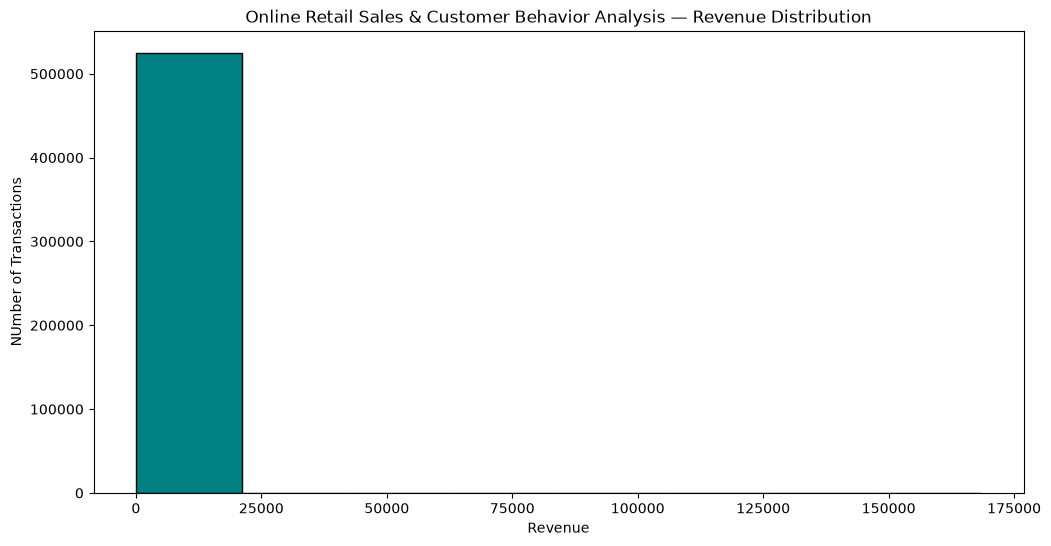

In [206]:
plt.figure(figsize=(12 ,6))
plt.hist(sales_df["Revenue"],color="Teal" , bins=8 , edgecolor='black')
plt.title("Online Retail Sales & Customer Behavior Analysis — Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("NUmber of Transactions")
plt.savefig("C:/Users/vikasa s y/Downloads/Online-Retail-Sales-Analysis/images/Revenue.png" , dpi=300 , bbox_inches="tight")
plt.show()

In [ ]:
sales_df["Revenue"].describe()

count    524878.000000
mean         20.275399
std         271.693566
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64

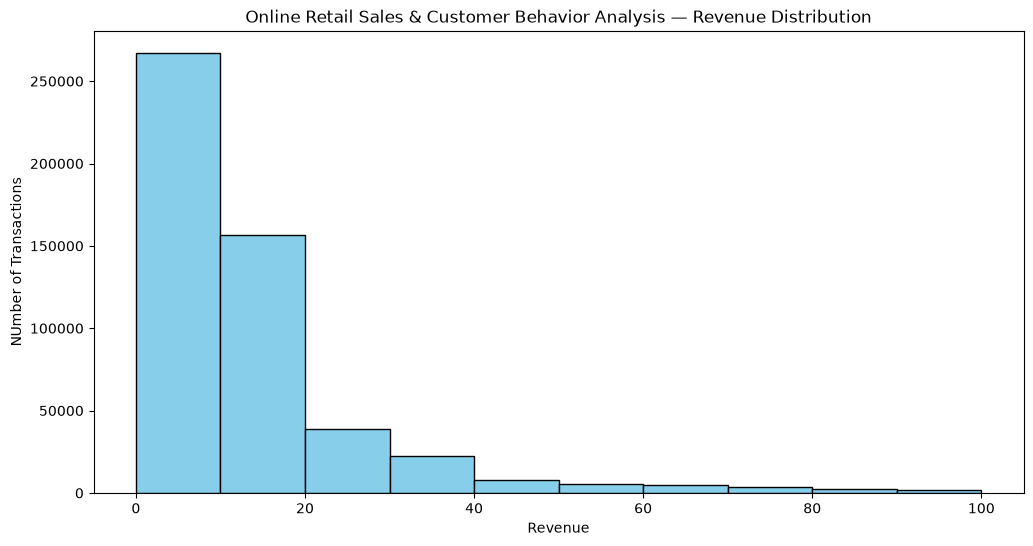

In [205]:
plt.figure(figsize=(12,6))
plt.hist(sales_df["Revenue"], range=(0,100) ,color="skyblue" , edgecolor='black')
plt.title("Online Retail Sales & Customer Behavior Analysis — Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("NUmber of Transactions")
plt.savefig("C:/Users/vikasa s y/Downloads/Online-Retail-Sales-Analysis/images/Revenue_range(0-100).png" , dpi=300 , bbox_inches="tight")
plt.show()

### Revenue Distribution

- Most transactions generate relatively low revenue.
- The number of transactions decreases as revenue increases.
- The revenue distribution is strongly right-skewed, with a small number of high-revenue transactions.
- The large difference between the typical revenue values and the maximum revenue indicates the presence of extreme high-value transactions.

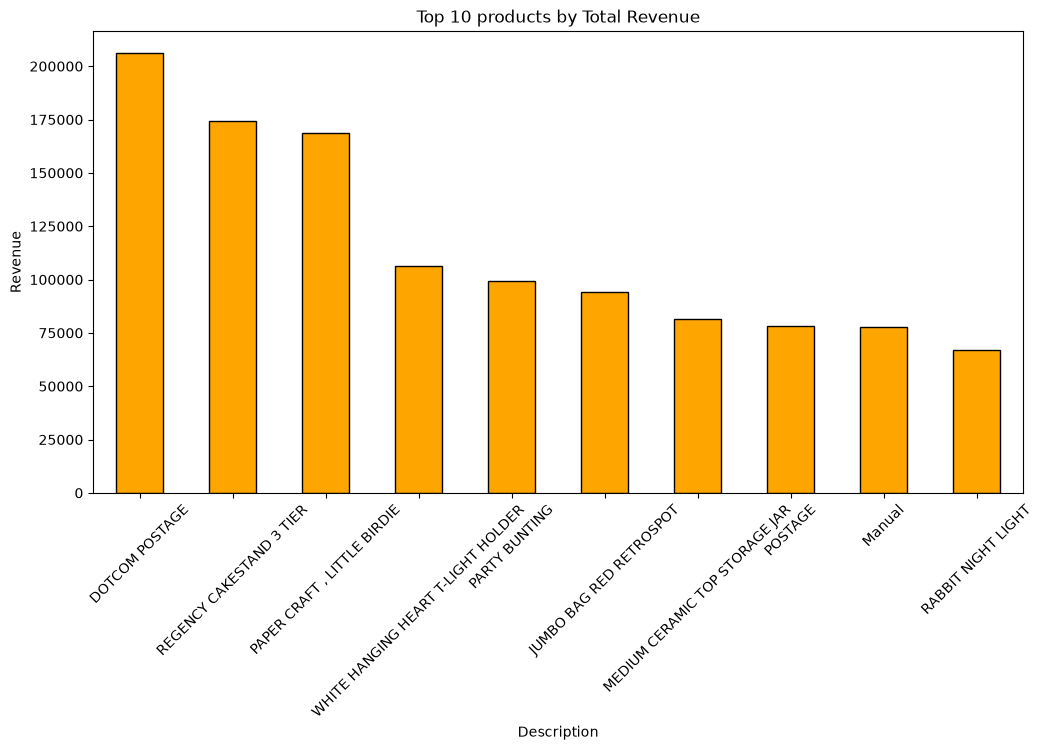

In [204]:
var = sales_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
var.plot(kind="bar" , color='orange' , edgecolor="black")
plt.title("Top 10 products by Total Revenue")
plt.xlabel("Description")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.savefig("C:/Users/vikasa s y/Downloads/Online-Retail-Sales-Analysis/images/Top 10 products-by-revenue.png" , dpi=300 , bbox_inches="tight")
plt.show()

In [191]:
x = sales_df["Quantity"]

In [192]:
y = sales_df["Revenue"]

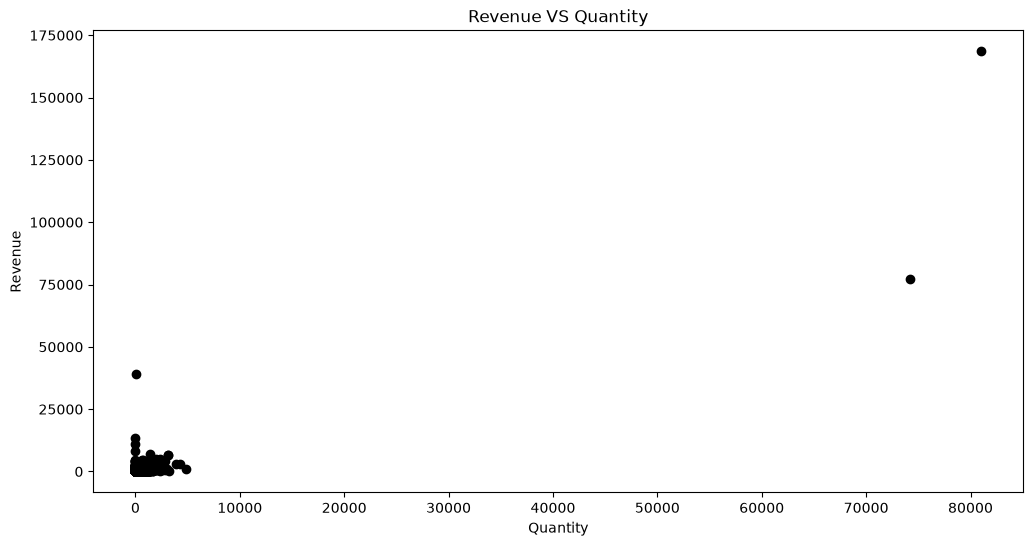

In [198]:
plt.figure(figsize=(12,6))
plt.scatter(x , y , color='black')
# plt.xlim(0 ,1000)
plt.title("Revenue VS Quantity")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.savefig("C:/Users/vikasa s y/Downloads/Online-Retail-Sales-Analysis/images/Quantity-vs-revenue.png" , dpi=300 , bbox_inches="tight")
plt.show()

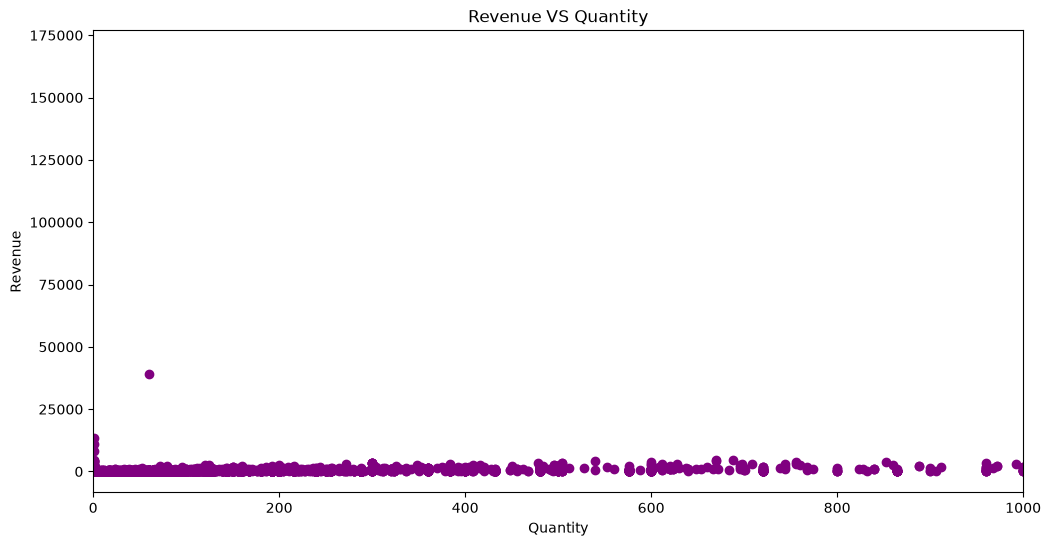

In [202]:
plt.figure(figsize=(12,6))
plt.scatter(x , y , color='purple')
plt.xlim(0 ,1000)
plt.title("Revenue VS Quantity")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.savefig("C:/Users/vikasa s y/Downloads/Online-Retail-Sales-Analysis/images/Q vs R (Zoomed vision).png" , dpi=300 , bbox_inches="tight")
plt.show()

### 💰 Revenue Analysis — Summary

- Most transactions generate relatively low revenue, while a small number of transactions contribute very high revenue.
- The revenue distribution is strongly right-skewed due to a small number of high-value transactions.
- The top revenue-generating products contribute significantly more revenue than most other products.
- The Quantity vs Revenue analysis does not show a clear linear relationship across all transactions.
- Extreme transactions were retained in the dataset because they may represent genuine business activity, while visualizations were adjusted where necessary to improve readability.